In [1]:
%pip install seaborn

In [66]:
from pyodide.http import pyfetch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [3]:
pd.set_option("display.max_columns", None)

<h1>I Download Data</h1>

In [4]:
async def download(url, filename):
    response = await pyfetch(url)
    try:
        if response.status == 200:
            print("connection to url successful")
            data = await response.bytes()
            with open(filename, "wb") as f:
                f.write(data)
                print(f"data successfully written in {filename}")
    except Exception as e:
        print("Error during download:", e)
    

In [5]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv'
filename = "laptop_price_data.csv"

await download(url, filename)

connection to url successful
data successfully written in laptop_price_data.csv


In [6]:
df = pd.read_csv(filename)
df.head()

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


In [7]:
df.columns.tolist()

['Unnamed: 0.1',
 'Unnamed: 0',
 'Manufacturer',
 'Category',
 'GPU',
 'OS',
 'CPU_core',
 'Screen_Size_inch',
 'CPU_frequency',
 'RAM_GB',
 'Storage_GB_SSD',
 'Weight_pounds',
 'Price',
 'Price-binned',
 'Screen-Full_HD',
 'Screen-IPS_panel']

In [8]:
df = df.drop(["Unnamed: 0.1","Unnamed: 0"], axis = 1)

In [9]:
df.head()

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


<h1>II Model Improvement</h1>

<h2>A. Data Preparation</h2>

<h3>1. Dependent and independent variables separation</h3>

In [10]:
x_data = df.drop(["Price"], axis = 1)
y_data = df["Price"]
y_data.head(1)

0    978
Name: Price, dtype: int64

<h3>2. Train and Test Data</h3>

In [11]:
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size = 0.1, random_state = 1)
print("Number of train sample and independent variables: ", X_train.shape)
print("Number of test sample: ", X_test.shape)

Number of train sample and independent variables:  (214, 13)
Number of test sample:  (24, 13)


<h2>B. Ordinary Least Square Regression</h2>


<h3>1. R2 for Train and Test Sets</h3>
<p>Dependent varibale : Price, Independent Variable: CPU_frequency</p>

In [12]:
X_train_OLS = X_train[["CPU_frequency"]]
X_test_OLS = X_test[["CPU_frequency"]]

In [13]:
model_OLS = LinearRegression()
model_OLS

LinearRegression()

In [14]:
model_OLS.fit(X_train_OLS, y_train)

LinearRegression()

In [15]:
R2_train_OLS = model_OLS.score(X_train_OLS, y_train)
R2_test_OLS = model_OLS.score(X_test_OLS, y_test)
print(f"""for the training set, R2 = {R2_train_OLS:.2f},
for the testing set, R2 = {R2_test_OLS:.2f}""")

for the training set, R2 = 0.15,
for the testing set, R2 = -0.07


<h3>2. R2 with 4 Folds Cross-Validation</h3>
<p>Dependent varibale : Price, Independent Variable: CPU_frequency</p>

In [16]:
R2_cross_validation = cross_val_score(model_OLS, X_train_OLS, y_train, cv = 4)
R2_cross_validation
mean_R2 = R2_cross_validation.mean()
std = R2_cross_validation.std()
print(f"""With a four fold cross validation, 
mean R2 (SD) = {mean_R2:.2f} ({std:.2f}),
R2 for the four subsets were:
R2_1 = {R2_cross_validation[0]:.2f},
R2_2 = {R2_cross_validation[1]:.2f},
R2_3 = {R2_cross_validation[2]:.2f},
R2_4 = {R2_cross_validation[3]:.2f}""")

With a four fold cross validation, 
mean R2 (SD) = 0.13 (0.08),
R2 for the four subsets were:
R2_1 = -0.01,
R2_2 = 0.21,
R2_3 = 0.13,
R2_4 = 0.18


<h3>3. Regression and Residual Plots </h3>

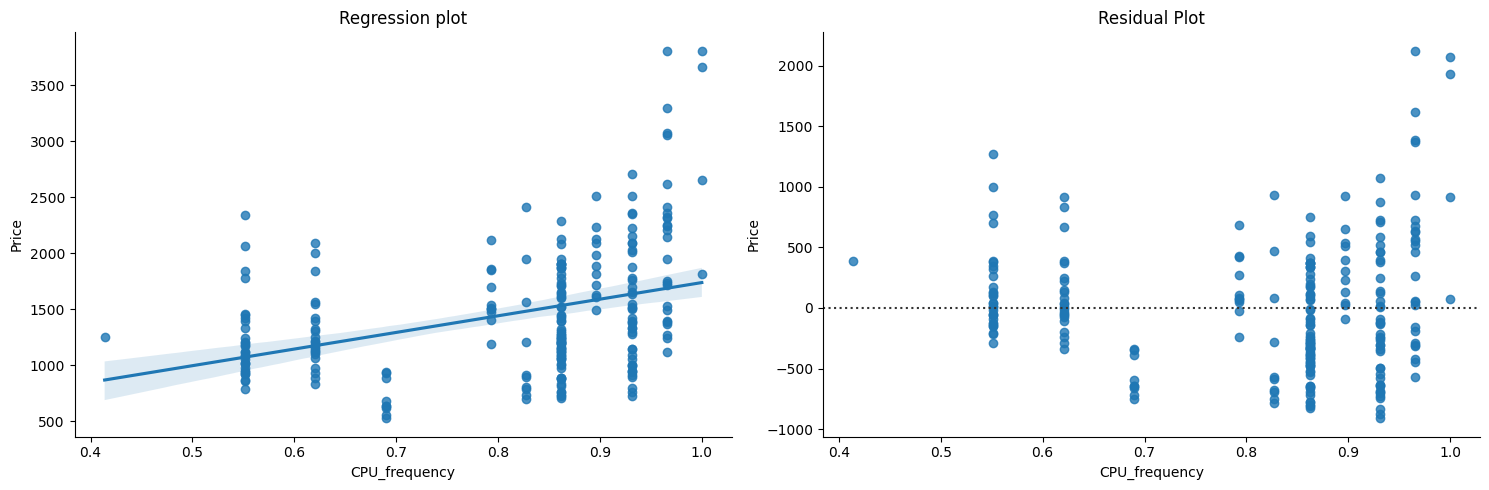

In [17]:
width = 15
height=5
fig, axes = plt.subplots(1,2, figsize = (width, height))
sns.regplot(x = "CPU_frequency", y = "Price", data = df, ax = axes[0])
sns.residplot(x = "CPU_frequency", y = "Price", data = df, ax = axes[1])
axes[0].set_title("Regression plot")
axes[1].set_title("Residual Plot")
sns.despine()
plt.tight_layout()
plt.show()

<p>The Ordinary Least Squares (OLS) model is inadequate for this data. CPU frequency alone does not capture the underlying factors influencing price, leading to poor fit and unreliable predictions. The patterns and variability in the residuals indicate that key assumptions of linear regression (linearity and constant variance) are violated. A more appropriate model would require additional explanatory variables and possibly a more flexible modeling approach.</p>

<h3>3. Results and Conclusion</h3>
<p>The Ordinary Least Squares model using CPU frequency to predict price showed weak explanatory power. The training set yielded an R² of 0.15, while the testing set produced a negative R² of −0.07, indicating poor generalization. Four-fold cross-validation gave a mean R² of 0.13 (SD = 0.08), with fold scores ranging from −0.01 to 0.21, suggesting high variability across subsets.

CPU frequency alone is a poor predictor of price. The low and inconsistent R² values—especially the negative test score—indicate that the model fails to capture the underlying relationship and does not generalize well. Additional features are needed to build a more reliable predictive model.</p>

<h2>C. Univariate polynomial Regression</h2>

<h3>1. Train and Test Data</h3>

In [18]:
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size = 0.5, random_state = 0)
print(X_train.shape)
print(X_test.shape)

(119, 13)
(119, 13)


In [19]:
X_train_poly = X_train[["CPU_frequency"]]
X_test_poly = X_test[["CPU_frequency"]]

<h3>2. R2 for Train and Test Data</h3>

In [20]:
model_poly = LinearRegression()

In [21]:
R2_train_array = []
R2_test_array = []
n_array = [1,2,3,4,5]
for n in n_array:
    poly_features = PolynomialFeatures(degree = n)
    X_train_poly_transformed = poly_features.fit_transform(X_train_poly)
    X_test_poly_transformed = poly_features.transform(X_test_poly)

    model_poly.fit(X_train_poly_transformed, y_train)

    R2_train = model_poly.score(X_train_poly_transformed, y_train)
    R2_train_array.append(R2_train)
    R2_test = model_poly.score(X_test_poly_transformed, y_test)
    R2_test_array.append(R2_test)
R2_train_array

[0.1678040501766731,
 0.37007804307858483,
 0.3755406739554136,
 0.40387769406587914,
 0.4172997182648498]

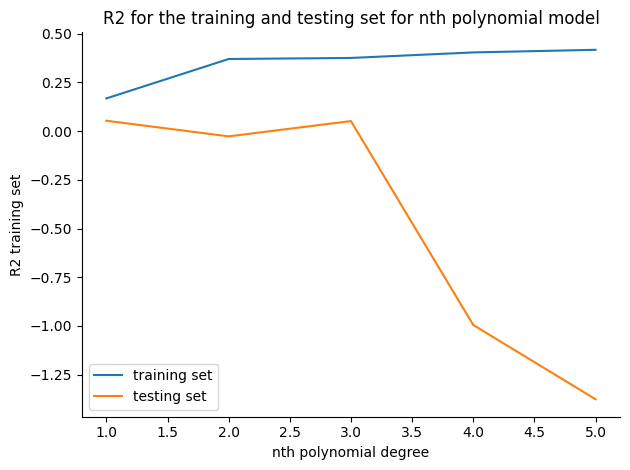

In [22]:
plt.plot(n_array, R2_train_array, label = "training set")
plt.plot(n_array, R2_test_array, label = "testing set")
plt.xlabel("nth polynomial degree")
plt.ylabel("R2 training set")
sns.despine()
plt.legend()
plt.title("R2 for the training and testing set for nth polynomial model")
plt.tight_layout()

<h3>3. Results and Conclusion</h3>

<p>The results show that as the polynomial degree increases, the model fits the training data better, reflected by the steadily rising R². However, the test R² improves only slightly up to around degree 2–3, then drops sharply into negative values for higher degrees. This indicates overfitting: the model becomes too complex and loses its ability to generalize to new data. Therefore, a polynomial degree of about 2 or 3 provides the best balance between bias and variance.</p>

<h2>D. Ridge Regression</h2>
<h3>Method 1</h3>
<p>Ride regression on 2nd degree multivariate polynomial model with 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU' and 'Category' as independent variables</p>

In [23]:
X_train_ridge = X_train[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU','Category']]
X_test_ridge = X_test[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU', 'Category']]

In [32]:
poly_features = PolynomialFeatures(degree = 2)
X_train_ridge_transformed = poly_features.fit_transform(X_train_ridge)
X_test_ridge_transformed = poly_features.transform(X_test_ridge)
X_test_ridge_transformed.shape

(119, 36)

In [37]:
from tqdm import tqdm

Alpha = np.arange(0.001,1, 0.001)
R2_train_ridge = []
R2_test_ridge = []
dummy = []
progress_bar = tqdm(Alpha)

for a in progress_bar:
    model_ridge = Ridge(alpha = a)
    model_ridge.fit(X_train_ridge_transformed, y_train)
    R2_train_a, R2_test_a = model_ridge.score(X_train_ridge_transformed, y_train), model_ridge.score(X_test_ridge_transformed, y_test)
    progress_bar.set_postfix({"train score": R2_train_a, "test score": R2_test_a})
    R2_train_ridge.append(R2_train_a)
    R2_test_ridge.append(R2_test_a)

100%|██████████| 999/999 [00:03<00:00, 281.88it/s, train score=0.669, test score=0.423]


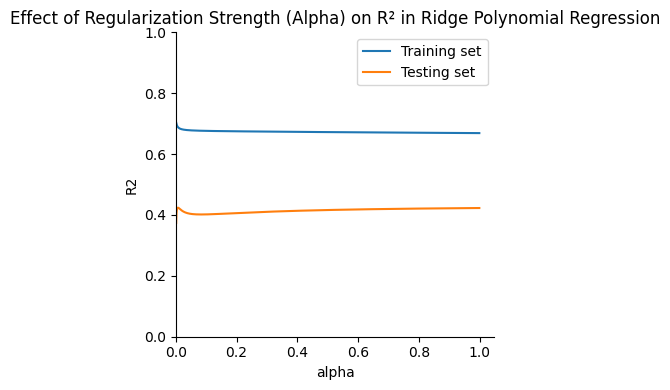

In [45]:
plt.figure(figsize = (4, 4))
plt.plot(Alpha, R2_train_ridge, label = "Training set")
plt.plot(Alpha, R2_test_ridge, label = "Testing set")
plt.title("Effect of Regularization Strength (Alpha) on R² in Ridge Polynomial Regression")
plt.xlabel("alpha")
plt.ylabel("R2")
plt.ylim(0,1)
plt.xlim(0,)
plt.legend()
sns.despine()
plt.tight_layout()

<p>The results show that the training R² remains relatively high while the test R² is consistently lower, indicating a moderate gap between training and test performance. This suggests the presence of mild to moderate overfitting, as the model fits the training data better than unseen data. Increasing the regularization parameter (alpha) slightly reduces this gap and stabilizes performance, leading to a modest improvement in generalization.</p>

<h3>Method 2: Grid Search </h3>

In [55]:
parameters_alpha = [{"alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]}]
model_ridge = Ridge()
grid_search = GridSearchCV(model_ridge, parameters_alpha, cv = 4)
grid_search.fit(X_train_ridge_transformed, y_train)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}])

In [58]:
best_alpha = grid_search.best_estimator_
best_alpha
best_R2 = best_alpha.score(X_test_ridge_transformed, y_test)
print(best_alpha, best_R2)

Ridge(alpha=10) 0.42236796465446913


<h3>Method 3: Ridge Multivariate Polynomial Regression with Cross-Validation and Scaling </h3>

In [74]:
standardization = StandardScaler()
X_train_poly_standardized = standardization.fit_transform(X_train_ridge_transformed)
X_test_poly_standardized = standardization.transform(X_test_ridge_transformed)

In [75]:
parameters_alpha = [{"alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]}]
model_ridge = Ridge()
grid_search = GridSearchCV(model_ridge, parameters_alpha, cv = 4)
grid_search.fit(X_train_poly_standardized, y_train)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}])

In [78]:
best_alpha = grid_search.best_estimator_
best_alpha
best_R2 = best_alpha.score(X_train_poly_standardized, y_train)
best_R2_test = best_alpha.score(X_test_poly_standardized, y_test)
print(best_alpha, best_R2, best_R2_test)

Ridge(alpha=1) 0.6652365152443083 0.4425981103249925


<h2>E. Ridge Multiple Regression with Cross Validation</h2>

In [61]:
X_train_multi = X_train[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU','Category']]
X_test_multi = X_test[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU', 'Category']]

parameters_alpha = [{"alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]}]
model_ridge = Ridge()
grid_search = GridSearchCV(model_ridge, parameters_alpha, cv = 4)
grid_search.fit(X_train_multi, y_train)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}])

In [65]:
best_alpha = grid_search.best_estimator_
best_R2_multi_train = best_alpha.score(X_train_multi, y_train)
best_R2_multi = best_alpha.score(X_test_multi, y_test)
print(best_alpha)
print(best_R2_multi_train)
print(best_R2_multi)

Ridge(alpha=10)
0.5455944716008576
0.3009905048691819


<p>The Ridge regression model was trained using multiple selected features, including CPU frequency, RAM size, SSD storage, CPU cores, operating system, GPU, and laptop category. To optimize the model, hyperparameter tuning was performed using GridSearchCV with cross-validation (cv = 4) over a range of alpha values from 0.0001 to 10.
The grid search identified α = 10 as the best regularization strength. Using this optimal parameter, the model achieved an R² score of approximately 0.546 on the training set and 0.301 on the test set.
These results indicate that while the model is able to capture some relationship between the features and the target variable in the training data, its performance on unseen data is significantly lower. This suggests that the model still has limited predictive power and may be affected by factors such as feature limitations, non-linear relationships, or remaining noise in the data.</p>

<h2>F. Ridge Multiple Regression with Cross Validation and Scaling </h2>

<p>StandardScaler is a preprocessing technique used to standardize features by removing the mean and scaling to unit variance. This transformation is important in many machine learning models, particularly those sensitive to feature scale such as Ridge regression, Logistic Regression, and Support Vector Machines, because it ensures that all variables contribute equally to the model regardless of their original units or magnitudes. By centering the data around zero and scaling it, StandardScaler improves numerical stability and can enhance the performance and convergence of optimization algorithms. The transformation is defined mathematically as:</p>
<p>
\[
z = \frac{x - \mu}{\sigma}
\]
</p>
<p>where \(x\) is the original feature value, \(\mu\) is the mean of the feature, \(\sigma\) is the standard deviation, and \(z\) is the standardized value.</p>

In [70]:
standardization = StandardScaler()
X_train_multi_standardized = standardization.fit_transform(X_train[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU','Category']])
X_test_multi_standardized = standardization.transform(X_test[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU', 'Category']])

In [71]:
parameters_alpha = [{"alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]}]
model_ridge = Ridge()
grid_search = GridSearchCV(model_ridge, parameters_alpha, cv = 4)
grid_search.fit(X_train_multi_standardized, y_train)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}])

In [72]:
best_alpha = grid_search.best_estimator_
best_R2_multi_train = best_alpha.score(X_train_multi_standardized, y_train)
best_R2_multi = best_alpha.score(X_test_multi_standardized, y_test)
print(best_alpha)
print(best_R2_multi_train)
print(best_R2_multi)

Ridge(alpha=10)
0.5741643492769637
0.36387419835432133


<p>After applying StandardScaler to the input features and training a Ridge regression model with hyperparameter tuning, the optimal regularization parameter was found to be α = 10. The model was evaluated using multiple linear regression with the selected features.

The final performance of the model resulted in an R² score of approximately 0.574 on the training set and 0.364 on the test set.

These results indicate that the model explains a moderate portion of the variance in the target variable, with improved generalization compared to unscaled or less optimized versions. The application of StandardScaler ensured that all features contributed equally to the model, preventing dominance by variables with larger scales and improving the stability of the Ridge regression coefficients.

However, the noticeable gap between training and test performance suggests that the model still has limitations in capturing all underlying patterns in the data.</p>

<h1>III Results and Conclusions</h1>

<p>Two regression approaches were evaluated for predicting laptop prices using the same feature set: CPU_frequency, RAM_GB, Storage_GB_SSD, CPU_core, OS, GPU, and Category, after applying StandardScaler.

For the multivariate linear regression (Ridge with α = 10), the model achieved a training R² of 0.574 and a test R² of 0.364, indicating a moderate ability to explain price variation with reasonable generalization performance.

For the polynomial regression of degree 2 (also Ridge with α = 10), the model achieved a training R² of 0.546 and a test R² of 0.301, showing lower predictive performance on unseen data compared to the linear model.

Overall, the results suggest that adding polynomial features did not improve model performance and instead led to weaker generalization, likely due to increased complexity and overfitting without sufficient additional signal in the data. In contrast, the scaled multiple linear regression provided the best balance between bias and variance, making it the more suitable model for this dataset.</p>